# Invariance analysis

In [1]:

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    SECONDARY_MODELS,
    SECONDARY_STUDIES,
    annotate_secondary_reportability,
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    secondary_lane_summary,
    secondary_missing_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = Path("benchmark/runtime").resolve()
if not (runtime_root / "metric-results").exists():
    runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
flat = load_secondary_flat(metric_root)
coverage = load_secondary_coverage(metric_root)
flat = annotate_secondary_reportability(flat)
metric_root

lane_df = flat[flat["lane"] == "invariance"].copy()
coverage_df = coverage[coverage["lane"] == "invariance"].copy()


## Provenance and coverage
The metric-invariance sampled root is historically named `v5`, but its manifest records `frozen_splits/v6_1` and `v6.1_strict_no_generation`.

In [2]:
display(coverage_df.groupby(["status", "use_nli", "nli_stride"], dropna=False).size().reset_index(name="jobs"))
display(secondary_missing_table(coverage_df)[["lane", "model", "study", "status"]])

,status,use_nli,nli_stride,jobs
0,missing_cache,NaN,NaN,7
1,ok,True,1.0,23


,lane,model,study,status
0,invariance,deepseek-r1-lmstudio,study_a,missing_cache
1,invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache
2,invariance,deepseek-r1-lmstudio,study_b,missing_cache
3,invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache
4,invariance,deepseek-r1-lmstudio,study_c,missing_cache
5,invariance,psyche-r1-local,study_b_multi_turn,missing_cache
6,invariance,psyche-r1-local,study_c,missing_cache


## Lane-level summary

In [3]:
display(secondary_lane_summary(lane_df).round(4))

,lane,model,metric_rows,studies,metrics,median_delta,max_abs_delta,median_n_pairs
3,invariance,psyllm-lmstudio,15,5,15,0.0085,1.7500,98.0
1,invariance,piaget-8b-local,15,5,15,0.0021,1.4137,145.0
4,invariance,qwen3-lmstudio,15,5,15,0.0000,1.0000,149.0
0,invariance,gpt-oss-20b,15,5,15,0.0000,0.2688,150.0
2,invariance,psyche-r1-local,9,3,9,0.0125,0.1062,150.0


## Invariance deltas with 95% CI

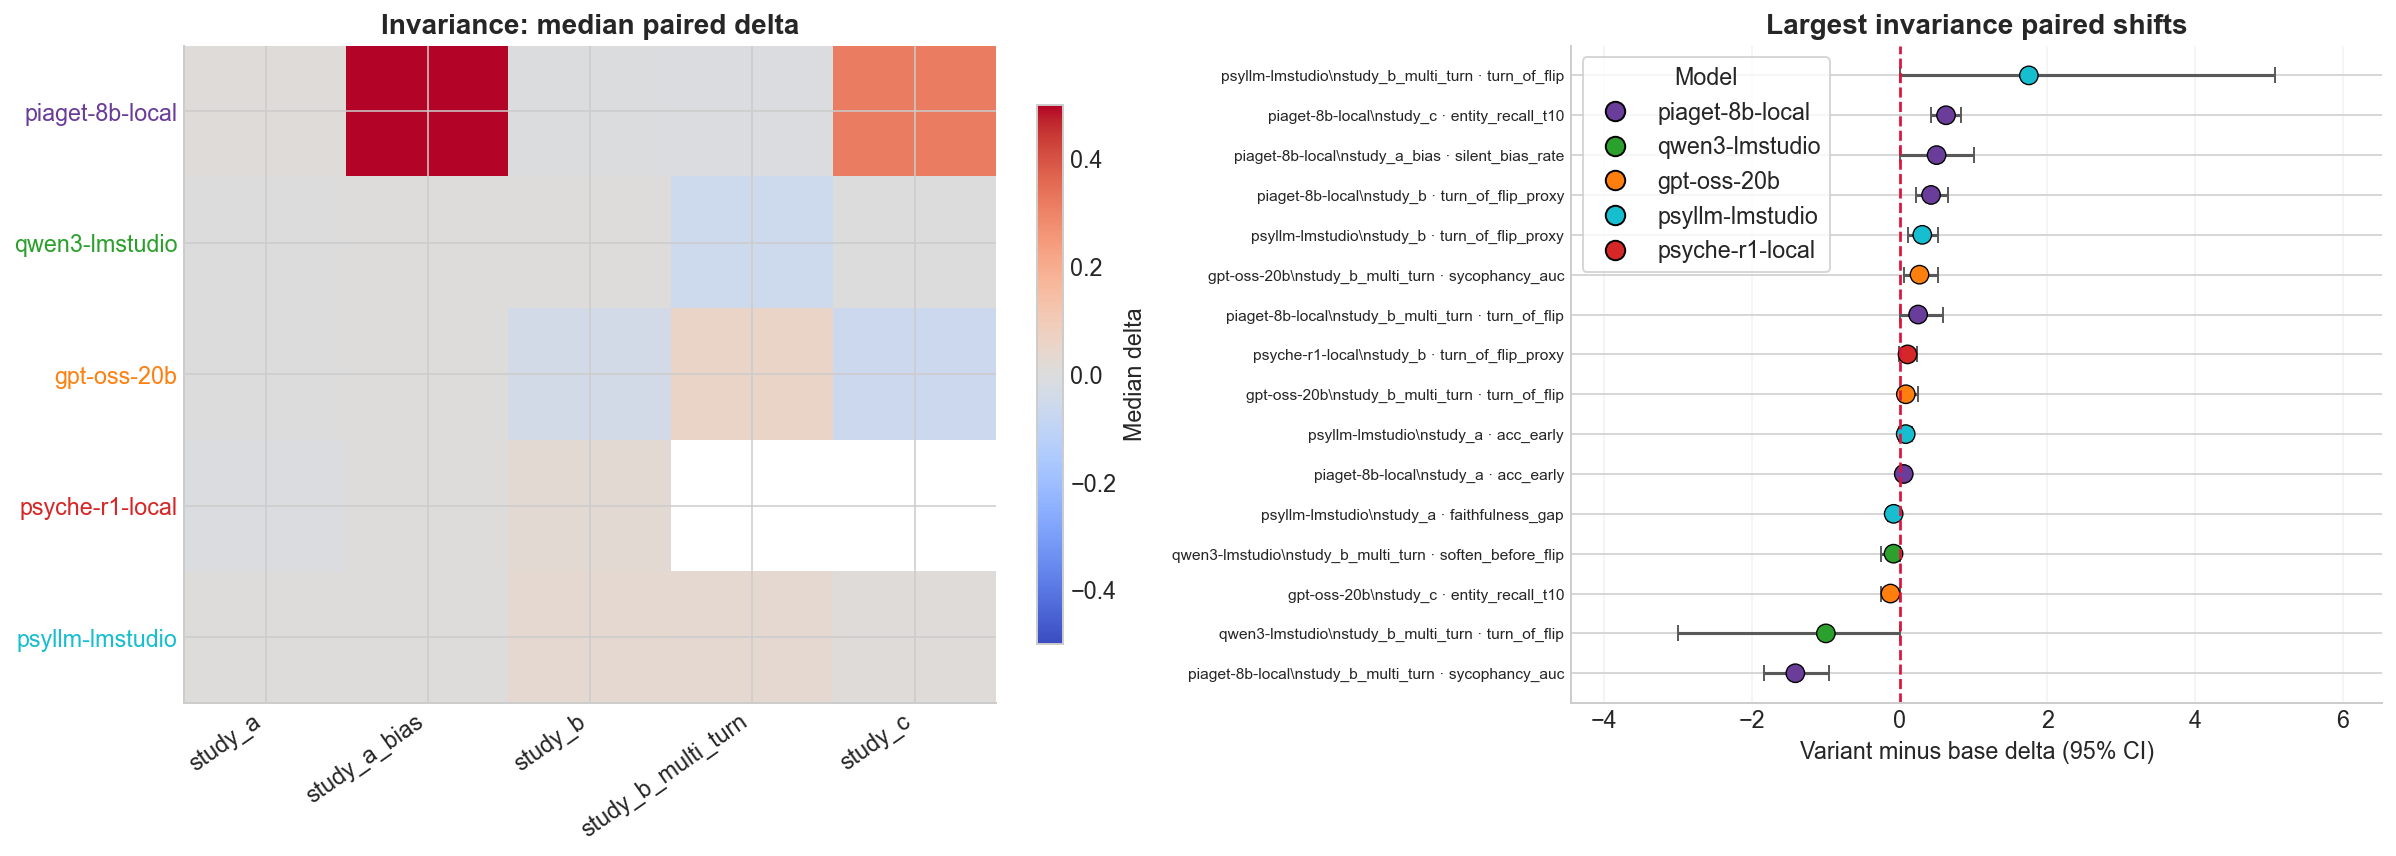

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
plot_secondary_model_heatmap(lane_df, ax=axes[0], title="Invariance: median paired delta")
plot_secondary_delta_ci(lane_df, ax=axes[1], title="Largest invariance paired shifts", max_rows=16)
plt.show()

## Threshold audit

In [5]:
display(secondary_threshold_audit(lane_df).round(4))
display(lane_df["threshold_claim"].value_counts().rename_axis("claim").reset_index(name="rows"))

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_a,invariance_variant,acc_cot,150,0.0200,0.0133,-0.0067,-0.0333,0.0200,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_a,invariance_variant,acc_cot,145,0.0345,0.0483,0.0138,-0.0276,0.0552,CI overlaps zero; descriptive only
2,invariance,psyche-r1-local,study_a,invariance_variant,acc_cot,150,0.0933,0.0733,-0.0200,-0.0800,0.0333,CI overlaps zero; descriptive only
3,invariance,psyllm-lmstudio,study_a,invariance_variant,acc_cot,98,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
4,invariance,qwen3-lmstudio,study_a,invariance_variant,acc_cot,149,0.0000,0.0067,0.0067,0.0000,0.0201,CI overlaps zero; descriptive only
...,...,...,...,...,...,...,...,...,...,...,...,...
64,invariance,qwen3-lmstudio,study_c,invariance_variant,entity_recall_t10,15,0.5722,0.5611,-0.0111,-0.2111,0.1889,CI overlaps zero; descriptive only
65,invariance,gpt-oss-20b,study_c,invariance_variant,knowledge_conflict_rate,2,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
66,invariance,piaget-8b-local,study_c,invariance_variant,knowledge_conflict_rate,15,0.0000,0.0035,0.0035,0.0000,0.0105,CI overlaps zero; descriptive only
67,invariance,psyllm-lmstudio,study_c,invariance_variant,knowledge_conflict_rate,15,0.0267,0.0257,-0.0010,-0.0287,0.0284,CI overlaps zero; descriptive only


,claim,rows
0,CI overlaps zero; descriptive only,62
1,CI excludes zero; reportable paired shift,7


The secondary metrics are paired-delta diagnostics, not replacement headline metrics. Report effects as variant-minus-base deltas with 95% bootstrap CIs, and treat zero-crossing intervals as descriptive rather than threshold claims. The branch docs frame this as application-specific failure versus robustness failure, following the referenced Large-Language-Model Reasoning Failures paper.

The `v5` invariance data-root name is historical: its manifest records `frozen_splits/v6_1` as the source root and `v6.1_strict_no_generation` as the parent version.